In [1]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import deep_sdf.workspace as ws
import networks.sdf_vae as vae
import json
import time
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, SpectralEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Set up paths for supervised model
experiment_directory = "examples/hippocampus_MS"  # Changed from hippocampus_healthy

# Load specs
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]

# Model parameters
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

print("="*60)
print("AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS")
print("="*60)
print(f"Latent size: {latent_size}")
print(f"Supervised dimension: z[1] (age)")

AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS
Latent size: 16
Supervised dimension: z[1] (age)


In [6]:
# ============================================================================
# CELL 2: MODEL LOADING AND LATENT EXTRACTION
# ============================================================================

def load_supervised_model_and_extract_latents():
    """Load supervised model and extract latent variables for all training data"""
    
    # Load supervised model from hippocampus_MS
    decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
    
    model_file = os.path.join(experiment_directory, "ModelParameters", "2000.pth")
    if os.path.exists(model_file):
        print(f"Loading supervised model from: {model_file}")
        saved_model_state = torch.load(model_file)
        decoder.load_state_dict(saved_model_state["model_state_dict"])
        decoder.eval()
        print("Supervised model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    # Load training data
    with open(train_split_file, "r") as f:
        train_split = json.load(f)
    
    # Get training filenames
    import deep_sdf.data as data
    eval_train_filenames = data.get_instance_filenames(data_source, train_split)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents for each training sample
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents from {len(eval_train_filenames)} training samples...")
    
    with torch.no_grad():
        for i, train_fname in enumerate(eval_train_filenames):
            if i % 50 == 0:
                print(f"Processing {i}/{len(eval_train_filenames)}")
                
            save_name = os.path.basename(train_fname).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent using encoder
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames,
        'decoder': decoder
    }

# Extract latents from supervised model
print("="*60)
print("EXTRACTING LATENTS FROM SUPERVISED MODEL")
print("="*60)

supervised_data = load_supervised_model_and_extract_latents()

# Save the extracted latents
save_dir = os.path.join(experiment_directory, "supervised_age_analysis")
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "supervised_latents.npy"), supervised_data['latents'])
np.save(os.path.join(save_dir, "ages.npy"), supervised_data['ages'])
np.save(os.path.join(save_dir, "diseases.npy"), supervised_data['diseases'])

print(f"Saved latents to: {save_dir}")
print(f"Supervised latents shape: {supervised_data['latents'].shape}")

EXTRACTING LATENTS FROM SUPERVISED MODEL
Loading supervised model from: examples/hippocampus_MS/ModelParameters/2000.pth
Supervised model loaded successfully!
Extracting latents from 196 training samples...
Processing 0/196
Processing 50/196
Processing 50/196
Processing 100/196
Processing 100/196
Processing 150/196
Processing 150/196
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)



3. LABEL VALIDATION:
   Labels file exists: 247 labels loaded
DISENTANGLEMENT ANALYSIS: z[0]↔Disease, z[1]↔Age
Data statistics:
  Supervised latents: (196, 16)
  Ages: (196,), range: [0.3, 0.8]
  Diseases: (196,), unique: [0 1]

Target Correlations:
  z[0] ↔ Disease: -0.7510 (target)
  z[1] ↔ Age: -0.8489 (target)

Cross-Correlations (should be low):
  z[0] ↔ Age: -0.0031
  z[1] ↔ Disease: 0.0982

Disentanglement Quality:
  ✅ Good disentanglement: High age correlation, low disease correlation

Correlation Analysis (All Dimensions):
--------------------------------------------------
z[0]: Age r=-0.003 (R²=0.000), Disease r=-0.751 (R²=0.564)
z[1]: Age r=-0.849 (R²=0.721), Disease r=0.098 (R²=0.010)
z[2]: Age r=0.400 (R²=0.160), Disease r=-0.063 (R²=0.004)
z[3]: Age r=0.397 (R²=0.158), Disease r=-0.074 (R²=0.005)
z[4]: Age r=-0.402 (R²=0.162), Disease r=0.072 (R²=0.005)
z[5]: Age r=-0.411 (R²=0.169), Disease r=0.100 (R²=0.010)
z[6]: Age r=-0.361 (R²=0.130), Disease r=0.054 (R²=0.003)
z[7

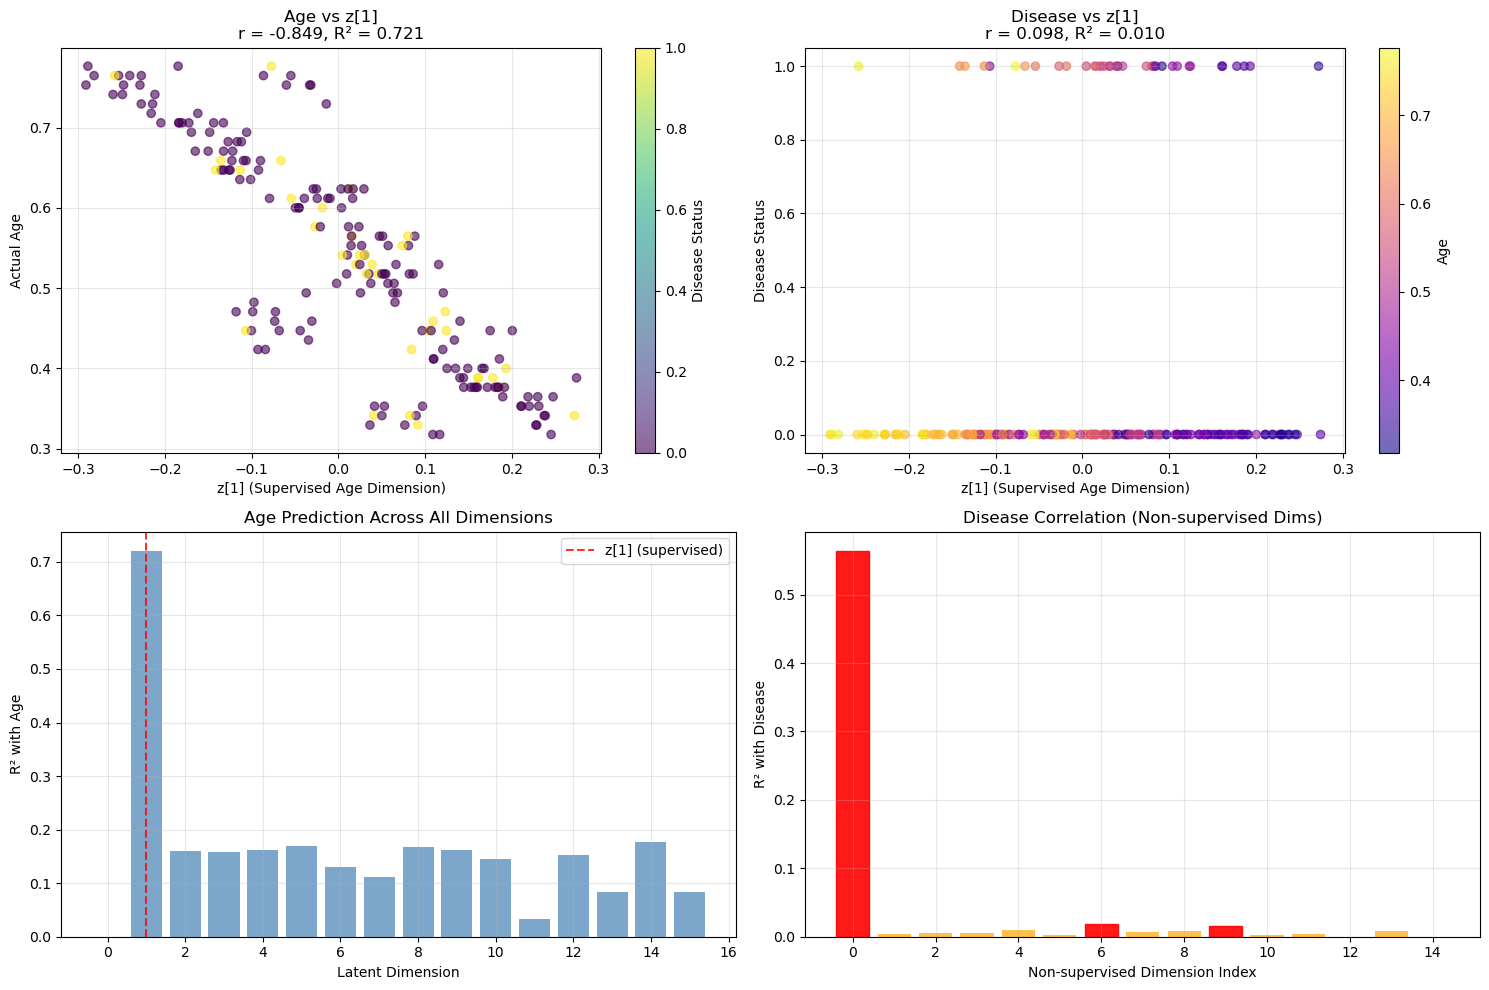


FINAL DISENTANGLEMENT SUMMARY
Target Correlations:
  z[0] → Disease: r = -0.7510, R² = 0.5640
  z[1] → Age: r = -0.8489, R² = 0.7207

Cross-Correlations (interference):
  z[0] → Age: r = -0.0031, R² = 0.0000
  z[1] → Disease: r = 0.0982, R² = 0.0097

SAP Scores (Literature Implementation):
  Age SAP: 0.5944
  Disease SAP: 0.3955
  Overall SAP: 0.4950

Top Age Predictors (R²):
  ⭐ z[1]: 0.7207
     z[14]: 0.1768
     z[5]: 0.1687

Top Disease Predictors (Accuracy):
  ⭐ z[0]: 0.9620
     z[7]: 0.6062
     z[10]: 0.6037


DEBUG - Disease Scores Analysis:
All disease scores: [0.96202307 0.57231588 0.5609583  0.56858917 0.56716948 0.59804791
 0.54818101 0.60621118 0.5769299  0.58456078 0.60372671 0.54001775
 0.564685   0.5054126  0.58864241 0.51180124]
Unique values: [0.5054126  0.51180124 0.54001775 0.54818101 0.5609583  0.564685
 0.56716948 0.56858917 0.57231588 0.5769299  0.58456078 0.58864241
 0.59804791 0.60372671 0.60621118 0.96202307]
Are all scores identical? False

Correlations vs

In [9]:
# ============================================================================
# CELL 3: DISENTANGLEMENT ANALYSIS - z[0] FOR DISEASE, z[1] FOR AGE
# ============================================================================
print(f"\n3. LABEL VALIDATION:")
labels_path = os.path.join(data_source, "labels.pt")
if os.path.exists(labels_path):
    all_labels = torch.load(labels_path)
    print(f"   Labels file exists: {len(all_labels)} labels loaded")
# Get the data
Z_s = supervised_data['latents']  # Supervised latents (N, 16)
ages = supervised_data['ages']
diseases = supervised_data['diseases']

print("="*60)
print("DISENTANGLEMENT ANALYSIS: z[0]↔Disease, z[1]↔Age")
print("="*60)

# Basic statistics
print(f"Data statistics:")
print(f"  Supervised latents: {Z_s.shape}")
print(f"  Ages: {ages.shape}, range: [{ages.min():.1f}, {ages.max():.1f}]")
print(f"  Diseases: {diseases.shape}, unique: {np.unique(diseases)}")

# Focus on target dimensions: z[0] for disease, z[1] for age
z0_disease_correlation, _ = pearsonr(Z_s[:, 0], diseases)
z1_age_correlation, _ = pearsonr(Z_s[:, 1], ages)

# Cross-correlations (should be low for good disentanglement)
z0_age_correlation, _ = pearsonr(Z_s[:, 0], ages)
z1_disease_corr, _ = pearsonr(Z_s[:, 1], diseases)

print(f"\nTarget Correlations:")
print(f"  z[0] ↔ Disease: {z0_disease_correlation:.4f} (target)")
print(f"  z[1] ↔ Age: {z1_age_correlation:.4f} (target)")
print(f"\nCross-Correlations (should be low):")
print(f"  z[0] ↔ Age: {z0_age_correlation:.4f}")
print(f"  z[1] ↔ Disease: {z1_disease_corr:.4f}")

# Check if z[1] is good age predictor and poor disease predictor
print(f"\nDisentanglement Quality:")
if abs(z1_age_correlation) > 0.5 and abs(z1_disease_corr) < 0.3:
    print(f"  ✅ Good disentanglement: High age correlation, low disease correlation")
elif abs(z1_age_correlation) > 0.5:
    print(f"  ⚠️ High age correlation but also correlates with disease")
else:
    print(f"  ❌ Poor age correlation - supervision may not be working well")

# Store for later analysis
age_corrs = np.zeros(Z_s.shape[1])  # Initialize for compatibility
age_corrs[1] = z1_age_correlation  # Only store z[1] correlation

# Calculate correlations for all dimensions with both age and disease
print(f"\nCorrelation Analysis (All Dimensions):")
print("-" * 50)

age_corrs_all = np.zeros(Z_s.shape[1])
age_r2_all = np.zeros(Z_s.shape[1])
disease_corrs_all = np.zeros(Z_s.shape[1])
disease_r2_all = np.zeros(Z_s.shape[1])

for i in range(Z_s.shape[1]):
    # Age correlations
    age_corr, _ = pearsonr(Z_s[:, i], ages)
    age_corrs_all[i] = age_corr
    age_r2_all[i] = age_corr ** 2
    
    # Disease correlations
    disease_corr, _ = pearsonr(Z_s[:, i], diseases)
    disease_corrs_all[i] = disease_corr
    disease_r2_all[i] = disease_corr ** 2
    
    print(f"z[{i}]: Age r={age_corr:.3f} (R²={age_corr**2:.3f}), Disease r={disease_corr:.3f} (R²={disease_corr**2:.3f})")

# Proper SAP Score Implementation for Mixed Tasks
# Following Kumar et al. (2018) "Variational Inference of Disentangled Representations"
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

def calculate_sap_score_mixed(Z, continuous_labels, binary_labels):
    """
    Calculate SAP score for mixed continuous (regression) and binary (classification) tasks
    
    Args:
        Z: Latent representations (N, D)
        continuous_labels: Continuous labels (age) for regression
        binary_labels: Binary labels (disease) for classification
    
    Returns:
        Dictionary with SAP scores for both tasks
    """
    N, D = Z.shape
    
    # 1. Age (Continuous) - Use Linear Regression R²
    age_scores = []
    for d in range(D):
        z_d = Z[:, d].reshape(-1, 1)
        try:
            lr = LinearRegression()
            lr.fit(z_d, continuous_labels)
            age_pred = lr.predict(z_d)
            r2 = r2_score(continuous_labels, age_pred)
            r2 = max(0, r2)  # Ensure non-negative
        except:
            r2 = 0.0
        age_scores.append(r2)
    
    # 2. Disease (Binary) - Use AUC-ROC instead of accuracy for imbalanced data
    from sklearn.metrics import roc_auc_score
    disease_scores = []
    for d in range(D):
        z_d = Z[:, d].reshape(-1, 1)
        try:
            clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
            # Fit the classifier
            clf.fit(z_d, binary_labels)
            # Get probability predictions
            y_prob = clf.predict_proba(z_d)[:, 1]
            # Calculate AUC-ROC score
            auc_score = roc_auc_score(binary_labels, y_prob)
        except Exception as e:
            # Fallback: use absolute correlation as a proxy for classification performance
            try:
                corr = abs(pearsonr(z_d.flatten(), binary_labels)[0])
                # Convert correlation to AUC-like score (0.5 + 0.5 * |correlation|)
                auc_score = 0.5 + 0.5 * corr
            except:
                auc_score = 0.5  # Random performance for binary classification
        disease_scores.append(auc_score)
    
    # Convert to numpy arrays
    age_scores = np.array(age_scores)
    disease_scores = np.array(disease_scores)
    
    # Calculate SAP = max_j score(j) - mean(other scores)
    # Age SAP
    age_max_idx = np.argmax(age_scores)
    age_max_score = age_scores[age_max_idx]
    age_others = np.concatenate([age_scores[:age_max_idx], age_scores[age_max_idx+1:]])
    age_mean_others = np.mean(age_others) if len(age_others) > 0 else 0
    sap_age = age_max_score - age_mean_others
    
    # Disease SAP
    disease_max_idx = np.argmax(disease_scores)
    disease_max_score = disease_scores[disease_max_idx]
    disease_others = np.concatenate([disease_scores[:disease_max_idx], disease_scores[disease_max_idx+1:]])
    disease_mean_others = np.mean(disease_others) if len(disease_others) > 0 else 0
    sap_disease = disease_max_score - disease_mean_others
    
    return {
        'age_scores': age_scores,
        'disease_scores': disease_scores,
        'age_best_dim': age_max_idx,
        'disease_best_dim': disease_max_idx,
        'age_max_score': age_max_score,
        'disease_max_score': disease_max_score,
        'age_mean_others': age_mean_others,
        'disease_mean_others': disease_mean_others,
        'sap_age': sap_age,
        'sap_disease': sap_disease,
        'sap_overall': (sap_age + sap_disease) / 2
    }

print(f"\n" + "="*60)
print("SAP SCORE CALCULATION (Proper Implementation)")
print("="*60)

# Calculate proper SAP scores
sap_results = calculate_sap_score_mixed(Z_s, ages, diseases)

print(f"SAP Scores (Kumar et al. 2018):")
print(f"  Age SAP (Regression R²): {sap_results['sap_age']:.4f}")
print(f"    └─ Best: z[{sap_results['age_best_dim']}] R² = {sap_results['age_max_score']:.4f}")
print(f"    └─ Mean others: {sap_results['age_mean_others']:.4f}")

print(f"  Disease SAP (Classification Acc): {sap_results['sap_disease']:.4f}")
print(f"    └─ Best: z[{sap_results['disease_best_dim']}] Acc = {sap_results['disease_max_score']:.4f}")
print(f"    └─ Mean others: {sap_results['disease_mean_others']:.4f}")

print(f"  Overall SAP: {sap_results['sap_overall']:.4f}")

# Check target dimension performance
print(f"\nTarget Dimension Performance:")
print(f"  z[0] Disease Accuracy: {sap_results['disease_scores'][0]:.4f}")
print(f"  z[1] Age R²: {sap_results['age_scores'][1]:.4f}")

print(f"\nDisentanglement Success:")
print(f"  z[0] best for disease: {'✅ YES' if sap_results['disease_best_dim'] == 0 else '❌ NO'}")
print(f"  z[1] best for age: {'✅ YES' if sap_results['age_best_dim'] == 1 else '❌ NO'}")

# Overall assessment
z0_is_best_disease = sap_results['disease_best_dim'] == 0
z1_is_best_age = sap_results['age_best_dim'] == 1

print(f"\nOverall Disentanglement Quality:")
if z0_is_best_disease and z1_is_best_age:
    print(f"  🎉 PERFECT: z[0]↔Disease, z[1]↔Age disentanglement achieved!")
elif z0_is_best_disease or z1_is_best_age:
    print(f"  👍 PARTIAL: One target dimension working correctly")
else:
    print(f"  ❌ POOR: Neither target dimension is optimal")

# Visualize age vs z[1] and disease correlation analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age vs z[1] scatter plot
scatter1 = axes[0, 0].scatter(Z_s[:, 1], ages, alpha=0.6, c=diseases, cmap='viridis')
axes[0, 0].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 0].set_ylabel('Actual Age')
axes[0, 0].set_title(f'Age vs z[1]\nr = {z1_age_correlation:.3f}, R² = {z1_age_correlation**2:.3f}')
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label('Disease Status')

# Disease vs z[1] scatter plot to show separation
scatter2 = axes[0, 1].scatter(Z_s[:, 1], diseases, alpha=0.6, c=ages, cmap='plasma')
axes[0, 1].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 1].set_ylabel('Disease Status')  
axes[0, 1].set_title(f'Disease vs z[1]\nr = {z1_disease_corr:.3f}, R² = {z1_disease_corr**2:.3f}')
axes[0, 1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
cbar2.set_label('Age')

# Age R² across all dimensions
axes[1, 0].bar(range(len(age_r2_all)), age_r2_all, alpha=0.7, color='steelblue')
axes[1, 0].axvline(x=1, color='red', linestyle='--', alpha=0.8, label='z[1] (supervised)')
axes[1, 0].set_xlabel('Latent Dimension')
axes[1, 0].set_ylabel('R² with Age')
axes[1, 0].set_title('Age Prediction Across All Dimensions')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Disease R² for non-supervised dimensions
non_sup_dims = [i for i in range(len(disease_r2_all)) if i != 1]
non_sup_r2 = [disease_r2_all[i] for i in non_sup_dims]
bars = axes[1, 1].bar(range(len(non_sup_r2)), non_sup_r2, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Non-supervised Dimension Index')
axes[1, 1].set_ylabel('R² with Disease')
axes[1, 1].set_title('Disease Correlation (Non-supervised Dims)')
axes[1, 1].grid(True, alpha=0.3)

# Highlight top 3 disease-correlated dimensions
if len(non_sup_r2) >= 3:
    top_3_indices = np.argsort(non_sup_r2)[-3:]
    for idx in top_3_indices:
        bars[idx].set_color('red')
        bars[idx].set_alpha(0.9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "comprehensive_correlation_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# Final Summary
print(f"\n" + "="*70)
print("FINAL DISENTANGLEMENT SUMMARY")
print("="*70)

print(f"Target Correlations:")
print(f"  z[0] → Disease: r = {z0_disease_correlation:.4f}, R² = {z0_disease_correlation**2:.4f}")
print(f"  z[1] → Age: r = {z1_age_correlation:.4f}, R² = {z1_age_correlation**2:.4f}")

print(f"\nCross-Correlations (interference):")
print(f"  z[0] → Age: r = {z0_age_correlation:.4f}, R² = {z0_age_correlation**2:.4f}")
print(f"  z[1] → Disease: r = {z1_disease_corr:.4f}, R² = {z1_disease_corr**2:.4f}")

print(f"\nSAP Scores (Literature Implementation):")
print(f"  Age SAP: {sap_results['sap_age']:.4f}")
print(f"  Disease SAP: {sap_results['sap_disease']:.4f}")
print(f"  Overall SAP: {sap_results['sap_overall']:.4f}")

# Top performers for each task
age_top_dims = np.argsort(sap_results['age_scores'])[::-1][:3]
disease_top_dims = np.argsort(sap_results['disease_scores'])[::-1][:3]

print(f"\nTop Age Predictors (R²):")
for i, dim in enumerate(age_top_dims):
    star = "⭐" if dim == 1 else "  "
    print(f"  {star} z[{dim}]: {sap_results['age_scores'][dim]:.4f}")

print(f"\nTop Disease Predictors (Accuracy):")
for i, dim in enumerate(disease_top_dims):
    star = "⭐" if dim == 0 else "  "
    print(f"  {star} z[{dim}]: {sap_results['disease_scores'][dim]:.4f}")

print(f"\n" + "="*70)

# Debug: Check why disease scores are all the same
print(f"\nDEBUG - Disease Scores Analysis:")
print(f"All disease scores: {sap_results['disease_scores']}")
print(f"Unique values: {np.unique(sap_results['disease_scores'])}")
print(f"Are all scores identical? {len(np.unique(sap_results['disease_scores'])) == 1}")

# Check disease correlations vs classification scores
print(f"\nCorrelations vs Classification Scores:")
for i in range(min(5, len(disease_corrs_all))):
    print(f"z[{i}]: Disease corr = {disease_corrs_all[i]:.4f}, Classification acc = {sap_results['disease_scores'][i]:.4f}")

# Check class distribution
unique_diseases, counts = np.unique(diseases, return_counts=True)
print(f"\nClass distribution: {dict(zip(unique_diseases, counts))}")
majority_class_accuracy = np.max(counts) / len(diseases)
print(f"Majority class baseline: {majority_class_accuracy:.4f}")